In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler 

## step 3: data cleaning and preprocessing

In [10]:
# read the file
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Data science project datasets\house predcton dataset.csv")
print(df.shape)
print(df.describe)
print(df.head())
print(df.dtypes)

# drop columns that are not necessary 
print(df.drop(columns=['date','street','country'], inplace = True))

# handle missing values zero values annomalies
df = df[df["price"] > 0].copy()

# convert state zip to categorical data type
df['statezip'] = df['statezip'].astype("category")

# check the remaining columns
print(df.columns)

(4600, 18)
<bound method NDFrame.describe of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterf

 ## Observation step 1
 We dropped date, street and country because they introduce noise as the country column is constant and street is too unique for the set


## Step 4: Exploratory Data Analysis

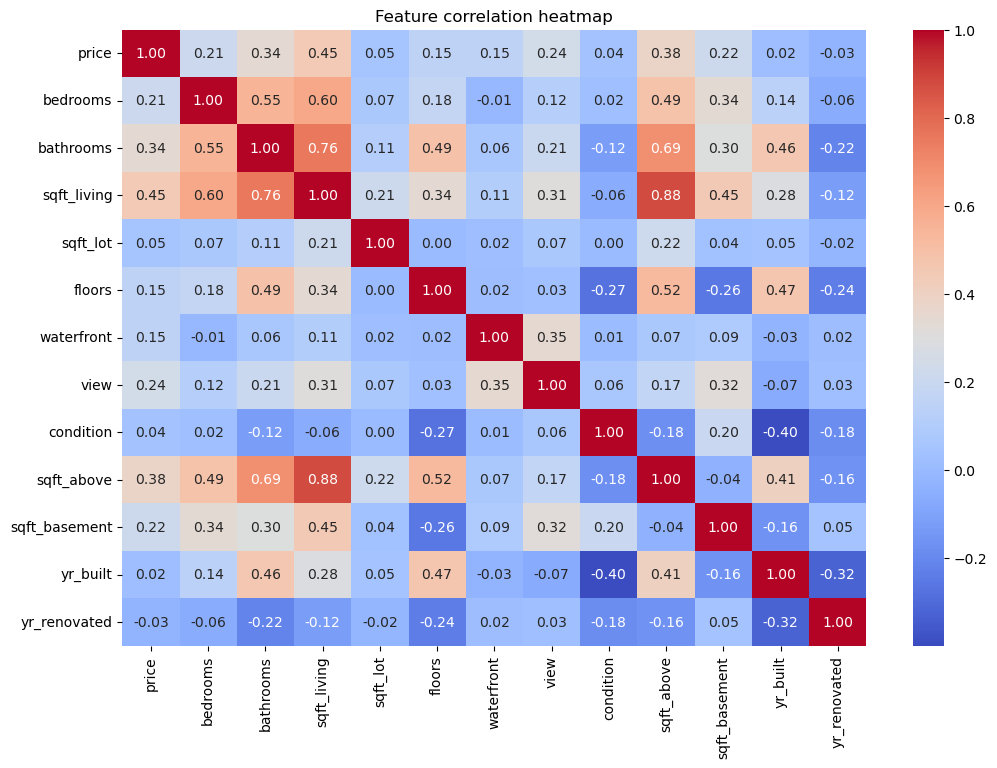

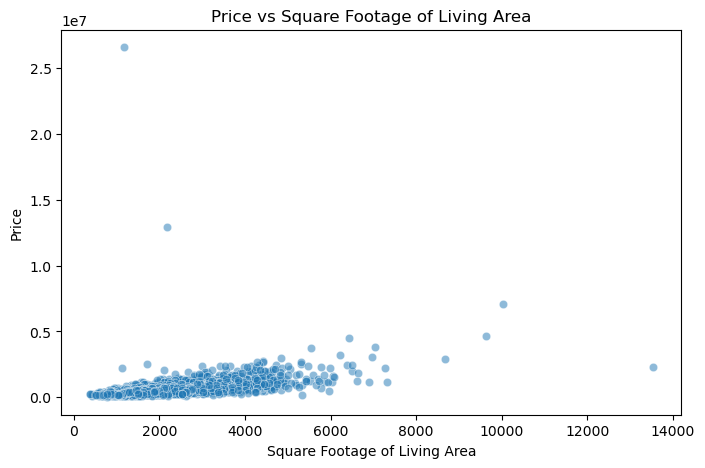

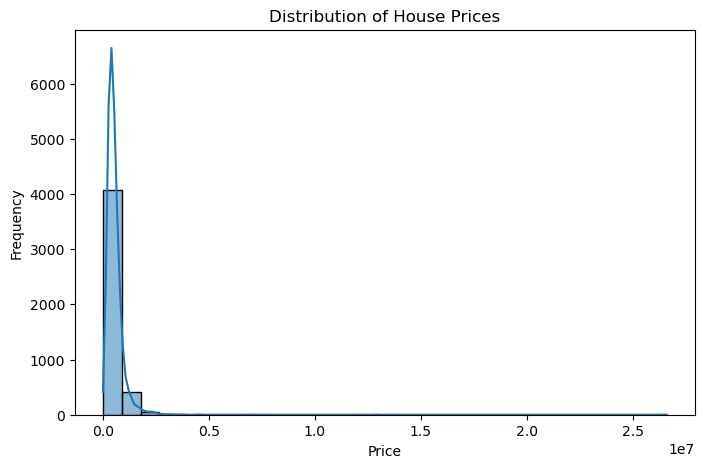

Skewness of price: 25.023817262008482


In [12]:
# a correlation heatmap for the numerical numbers
plt.figure(figsize= (12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns. heatmap(corr,annot = True, cmap = "coolwarm", fmt=".2f")
plt.title("Feature correlation heatmap")
plt.show()


# Scatter plot: sqft_living vs price
# Scatter plot shows the relationship between living area and price.
# Points far from the main cluster may represent outliers or special high-value houses.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="sqft_living", y="price", alpha=0.5)
plt.title("Price vs Square Footage of Living Area")
plt.xlabel("Square Footage of Living Area")
plt.ylabel("Price")
plt.show()

# Histogram to show the skewness of house prices
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()
# to understand the skewness of price distribution.
# Print skewness value
print("Skewness of price:", df["price"].skew())

## Feature Engineering
An algorithm understands numbers better than raw years. Converting yr_built to house_age provides a continuous scale. Since yr_renovated contains many zeros, converting it to a binary is_renovated feature captures the impact of a renovation perfectly. We one-hot encoded the city because location heavily dictates real estate prices.

## 6. Model building
we split the data to ensure we test the model on unseen data, preventing overfitting. Standard Scaling ensures all numerical features contribute equally

In [13]:
# Feature Engineering
# Create useful features from year columns and encode categorical variables.

current_year = pd.Timestamp.now().year

# Create house age
df["house_age"] = current_year - df["yr_built"]

# Create renovation flag captures whether a house was renovated or not.
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

# Drop original year columns
df = df.drop(columns=["yr_built", "yr_renovated"])

# One-hot encode categorical columns for modeling
df = pd.get_dummies(df, columns=["city", "statezip"], drop_first=True)

# Split features and target
X = df.drop(columns=["price"])# preidctor features include everything except the target variable(price)
y = df["price"] # this is the target variable we want to predict

In [7]:
# convert categorical columns to numeric before splitting
if 'statezip' in X.columns:
	X = pd.get_dummies(X, columns=['statezip'], drop_first=True)

# split data: 80% training and 20% testing : test checking the model performance on unseen data reduce overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# scale numerical feature for good distance-based algorithms standardizes feature values to have mean of 0 and standard deviation of 1, which helps improve model performance and convergence.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initialize and train the model create a Random Forest Regressor model with 100 trees and a fixed random state for reproducibility. Fit the model to the scaled training data.
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train_scaled, y_train)

# generate prediction of the houses
y_pred = model.predict(X_test_scaled)


## 7: Model Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

# Baseline model: predicts the mean house price
baseline_model = DummyRegressor(strategy="mean") # the algorithm predicts the mean of the target variable (house price) for all instances in the test set. This serves as a simple benchmark to compare the performance of more complex models.
baseline_model.fit(X_train_scaled, y_train)
baseline_pred = baseline_model.predict(X_test_scaled)

# Random Forest evaluation
rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

# Baseline evaluation
base_mae = mean_absolute_error(y_test, baseline_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
base_r2 = r2_score(y_test, baseline_pred)

print("Random Forest:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

print("\nBaseline Model:")
print("MAE:", base_mae)
print("RMSE:", base_rmse)
print("R2:", base_r2)

Random Forest:
MAE: 156406.50442240466
RMSE: 985391.3589545712
R2: 0.04789957846046977

Baseline Model:
MAE: 277797.2859384382
RMSE: 1010500.7773258204
R2: -0.0012408544693358614
